## Ocean T,S, $\rho$

Using WOCE atlas.

In [1]:
# load libraries, read time series data:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from netCDF4 import Dataset
import cartopy.crs as ccrs
import matplotlib.ticker as mticker
from datetime import datetime, timedelta
import matplotlib.patches as mpatches
import pickle
import gsw as gsw

# read Data:
data_dir="../../Data-for-teaching-staff/Ocean-circulation/WOCE/"
file_S="woa13_decav_s00_01v2.nc"
file_T="woa13_decav_t00_01v2.nc"
ncfile_S = Dataset(data_dir+file_S, 'r');
ncfile_T = Dataset(data_dir+file_T, 'r');
lat = ncfile_T.variables['lat'][:]
lon = ncfile_T.variables['lon'][:]
depth=np.asarray(ncfile_T.variables['depth'][:])/1000.0
T=np.asarray(ncfile_T.variables['t_an'][:])
T[T>1.e36]=np.nan
S=np.asarray(ncfile_S.variables['s_an'][:])
S[S>1.e36]=np.nan

# calculate density from T,S:\
p=0
sigma=gsw.rho(S, T, p)-1000

# get grid/ time limits:
Nt,Nz,Ny,Nx=T.shape
print("dimensions of T,S:",T.shape)

# font required by PUP:
plt.rcParams['font.family'] = 'Myriad Pro'

print("done.")

dimensions of T,S: (1, 102, 180, 360)
done.


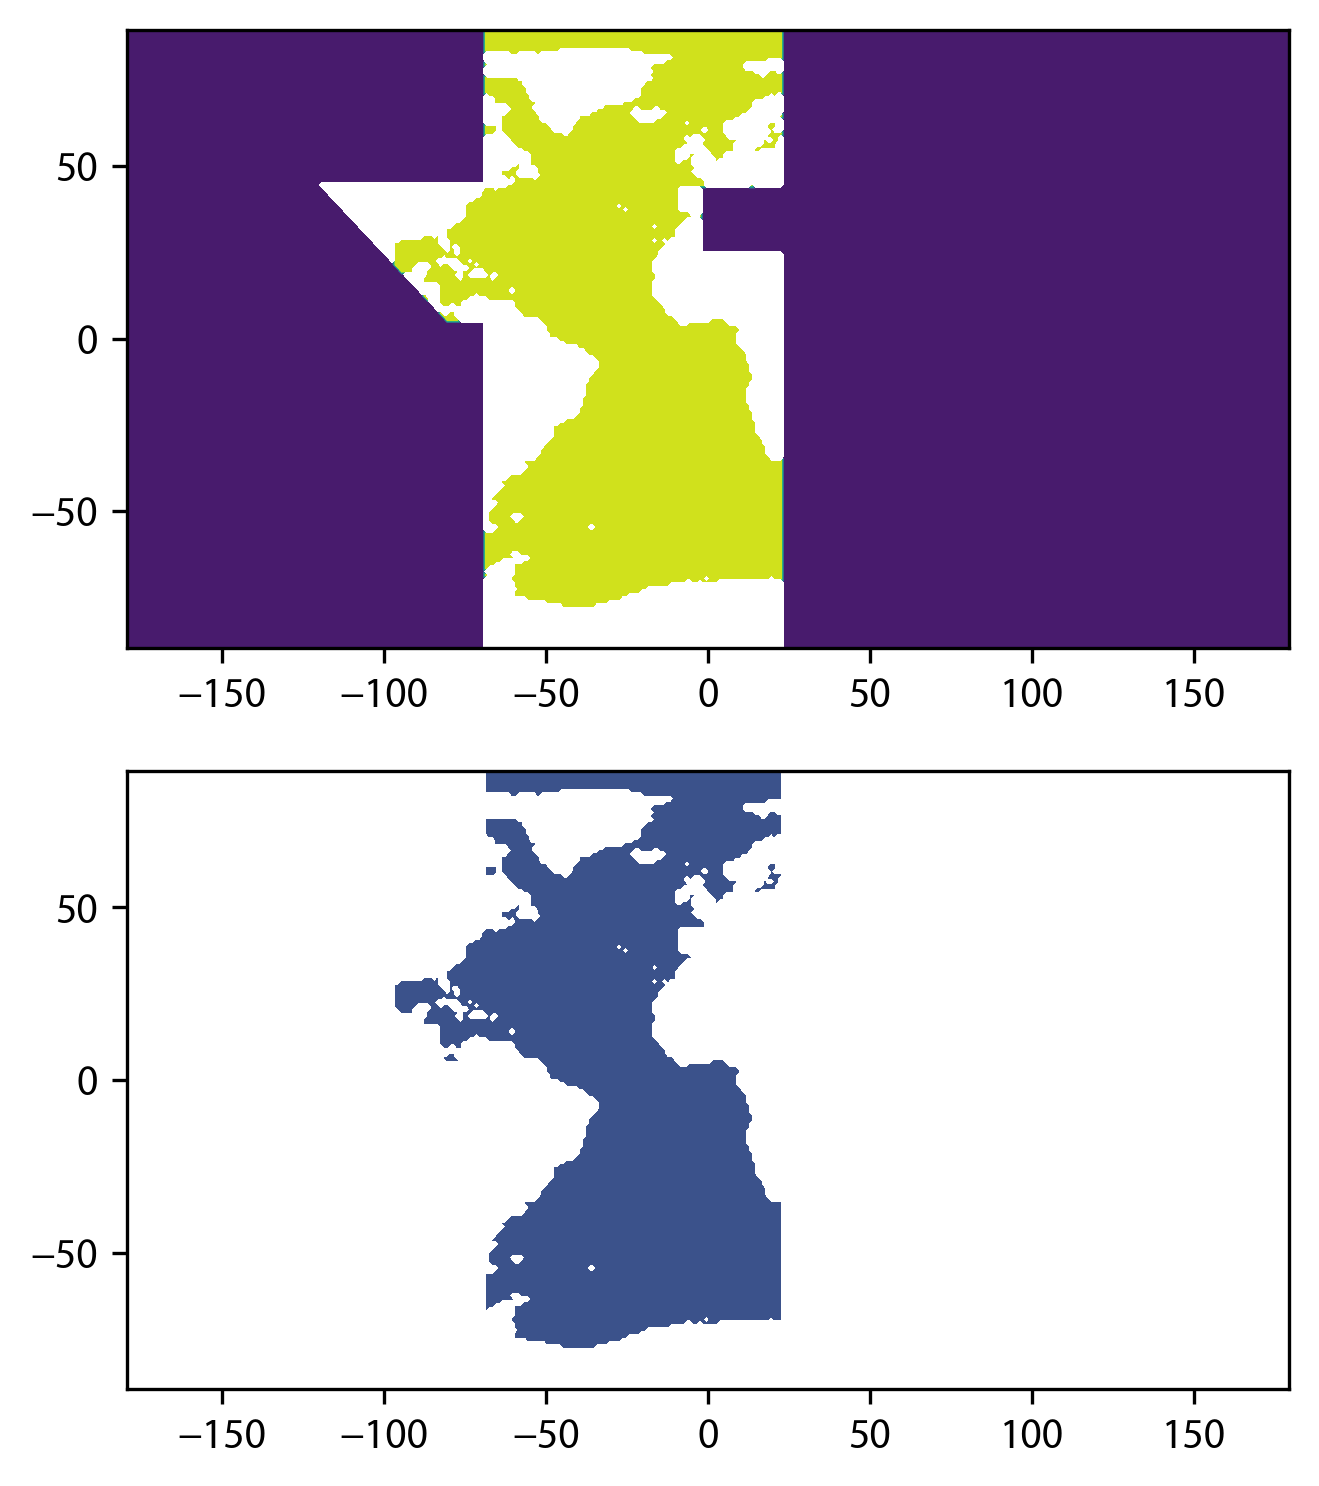

In [2]:
# calculate mask for Atlantic ocean:
longitude,latitude=np.meshgrid(lon,lat)
mask_Atlantic=1.0*T[0,0,:,:]
mask_Atlantic[~np.isnan(mask_Atlantic)]=1
# Drake passage
condition=np.logical_and(longitude<-69,latitude<5)
mask_Atlantic[condition]=0
# south Africa
condition=np.logical_and(longitude>23,latitude<90)
mask_Atlantic[condition]=0
# mediteranean:
condition=np.logical_and(np.logical_and(longitude>-2,latitude>25),latitude<44)
mask_Atlantic[condition]=0
# Arctic:
condition=np.logical_and(longitude<-69,latitude>45)
mask_Atlantic[condition]=0
# Pacific:
condition=np.logical_and(longitude+latitude<25-100,latitude>0)
mask_Atlantic[condition]=0

# plot mask to show masked areas:
fig=plt.figure(figsize=(5,6),dpi=300)
plt.subplot(2,1,1)
plt.contourf(lon,lat,mask_Atlantic)

# finalize mask:
mask_Atlantic[mask_Atlantic==0]=np.nan

# plot final mask:
plt.subplot(2,1,2)
plt.contourf(lon,lat,mask_Atlantic)

In [3]:
# calculate atlantic zonal averages:
# ----------------------------------
T_masked_Atl=np.zeros(T[0,:,:,:].shape)
S_masked_Atl=np.zeros(T[0,:,:,:].shape)
sigma_masked_Atl=np.zeros(T[0,:,:,:].shape)
for k in range(Nz):
    T_masked_Atl[k,:,:]=T[0,k,:,:]*mask_Atlantic
    S_masked_Atl[k,:,:]=S[0,k,:,:]*mask_Atlantic
    sigma_masked_Atl[k,:,:]=sigma[0,k,:,:]*mask_Atlantic

T_avg_Atl=np.nanmean(T_masked_Atl,axis=2)
S_avg_Atl=np.nanmean(S_masked_Atl,axis=2)
sigma_avg_Atl=np.nanmean(sigma_masked_Atl,axis=2)


# calculate averaged profiles:
# ----------------------------
T_profile_Atl=np.nanmean(T_masked_Atl[:,np.logical_and(lat>-30,lat<0),:],axis=(1,2))
S_profile_Atl=np.nanmean(S_masked_Atl[:,np.logical_and(lat>-30,lat<0),:],axis=(1,2))

print("done.")

done.


/var/folders/0v/wvw14yq11b34jdy4j2h8fsx80000gn/T/ipykernel_90796/4216822357.py:11: RuntimeWarning: Mean of empty slice
  T_avg_Atl=np.nanmean(T_masked_Atl,axis=2)
/var/folders/0v/wvw14yq11b34jdy4j2h8fsx80000gn/T/ipykernel_90796/4216822357.py:12: RuntimeWarning: Mean of empty slice
  S_avg_Atl=np.nanmean(S_masked_Atl,axis=2)
/var/folders/0v/wvw14yq11b34jdy4j2h8fsx80000gn/T/ipykernel_90796/4216822357.py:13: RuntimeWarning: Mean of empty slice
  sigma_avg_Atl=np.nanmean(sigma_masked_Atl,axis=2)


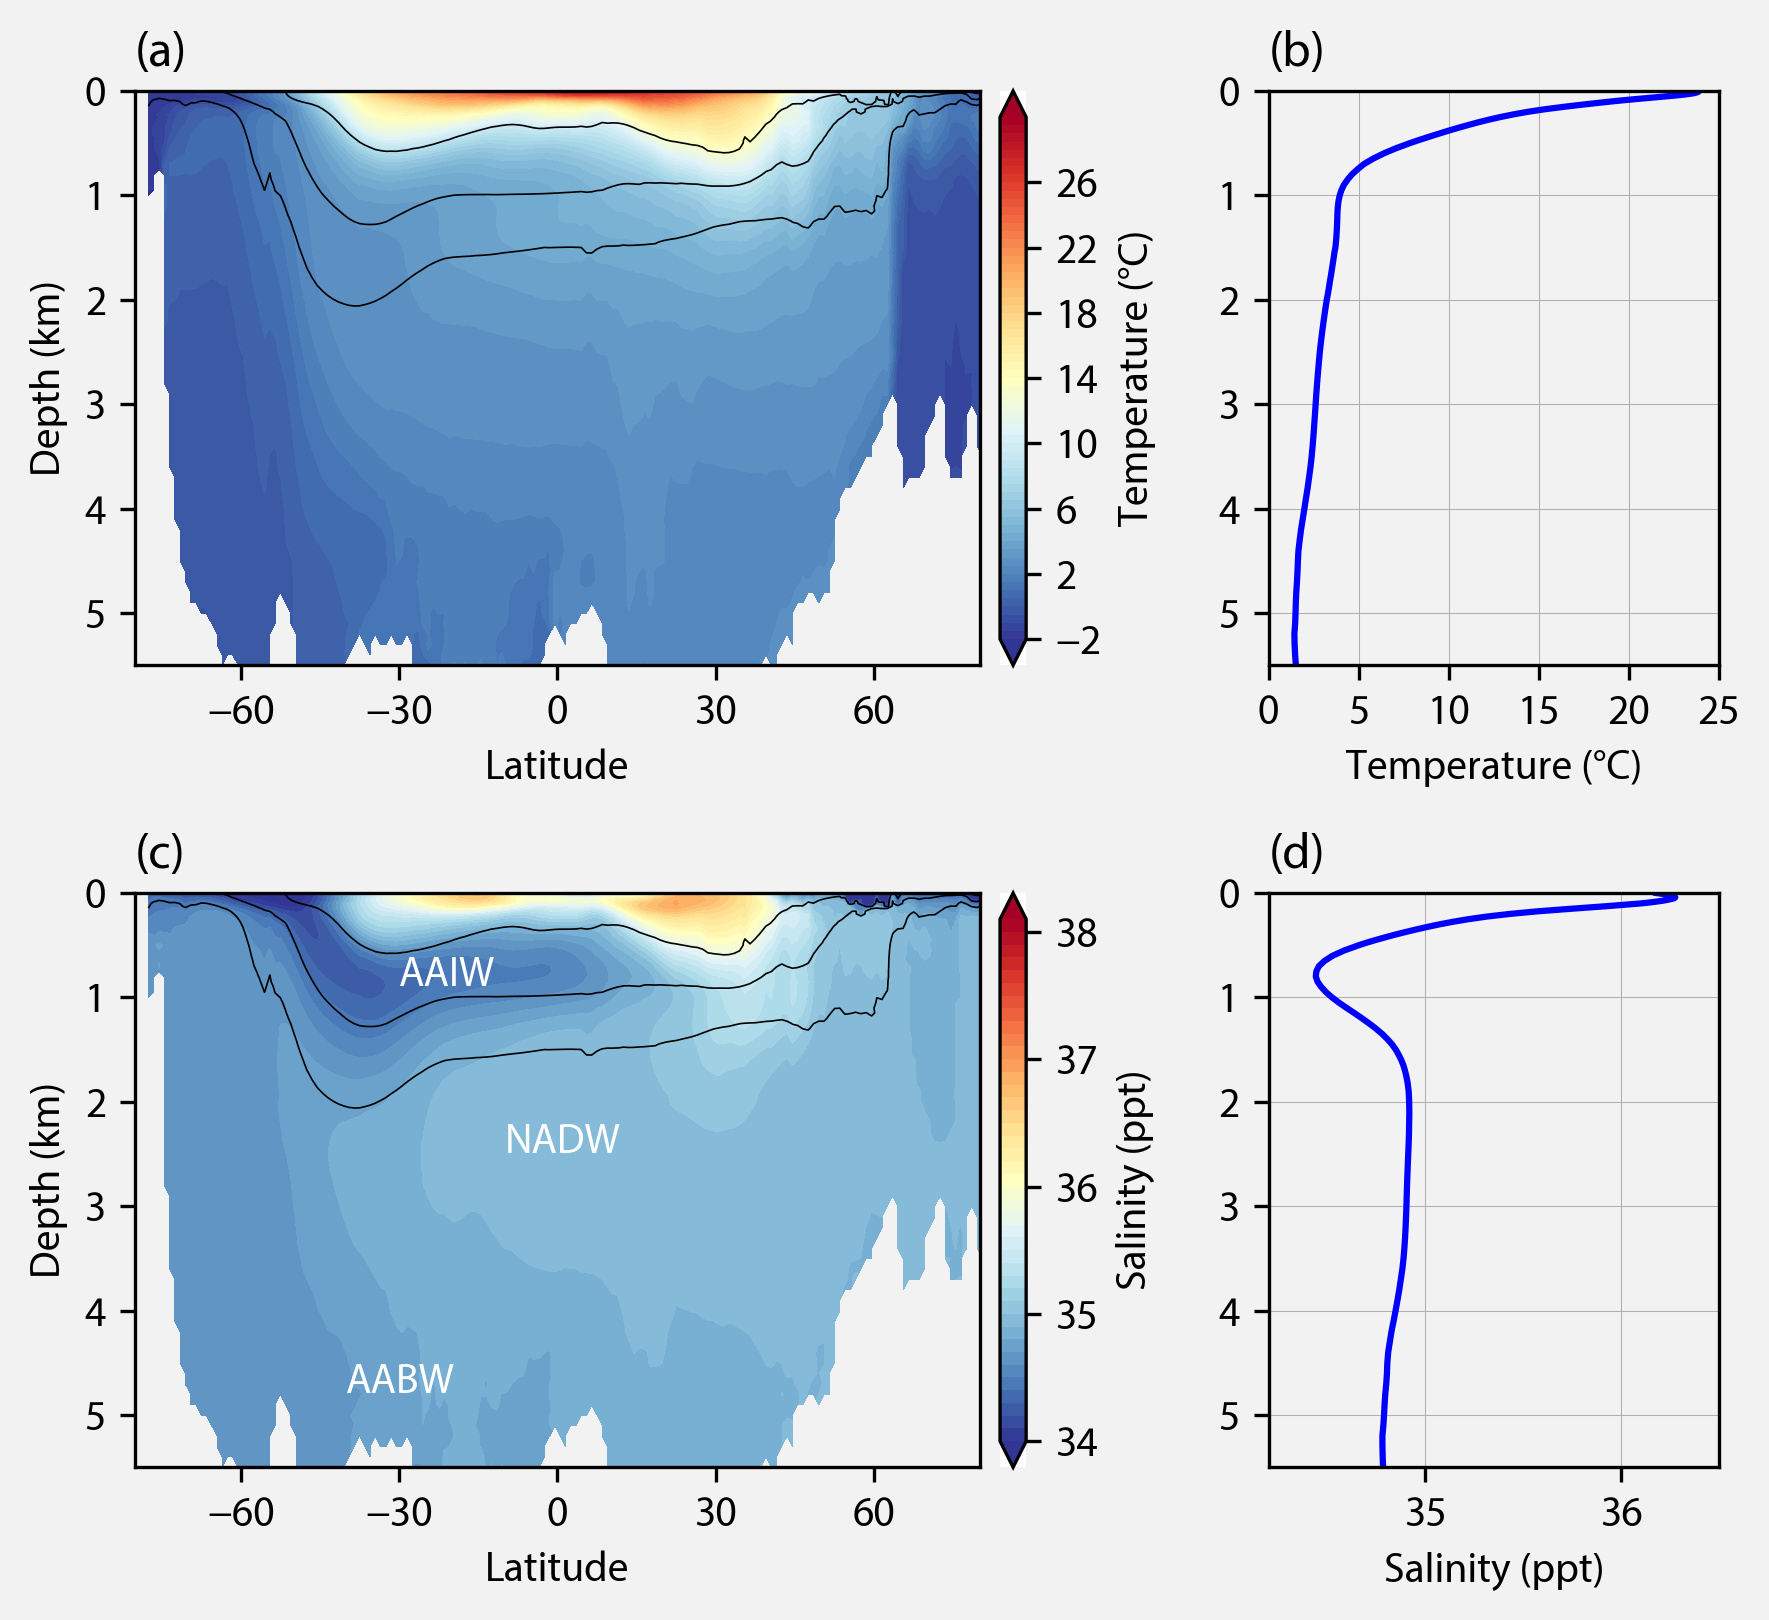

In [5]:
# zonally averaged and profile plots:
#props = dict(boxstyle='round', edgecolor="wheat", facecolor='wheat', alpha=0.9)
props1 = dict(boxstyle='round', edgecolor="none", facecolor='none', alpha=0.9)

fig=plt.figure(figsize=(6,5.5),dpi=300)
plt.subplot(2,3,(1,2))
levels=np.arange(-2,30.5,0.5)
plt.contourf(lat,depth,T_avg_Atl,levels=levels,extend='both')
plt.ylim(0,5.5)
ax=plt.gca()
ax.invert_yaxis()
ax.set_facecolor('#f2f2f2')
clb=plt.colorbar(ticks=range(-2,30,4),pad=0.02)
clb.set_label("Temperature (°C)")
levels1=[26.8,27.3,27.6]
ax.contour(lat,depth,sigma_avg_Atl,levels=levels1,colors="k",linewidths=0.4)
plt.xlabel("Latitude")
plt.ylabel("Depth (km)")
plt.xticks(range(-60,65,30))
plt.xlim(-80,80)
plt.title("(a)",loc="left")
#ax.text(0.88, 0.15, "(a)", transform=ax.transAxes, fontsize=12,
#        verticalalignment='top', bbox=props)

plt.subplot(2,3,3)
plt.plot(T_profile_Atl,depth,color="b")
plt.ylim(0,5.5)
ax=plt.gca()
ax.invert_yaxis()
ax.set_facecolor('#f2f2f2')
plt.xlabel("Temperature (°C)")
plt.xticks(range(0,30,5))
plt.grid(lw=0.25)
plt.title("(b)",loc="left")
#ax.text(0.79, 0.15, "(b)", transform=ax.transAxes, fontsize=12,
#        verticalalignment='top', bbox=props)

plt.subplot(2,3,(4,5))
ax=plt.gca()
plt.set_cmap('RdYlBu_r')
levels=np.arange(34,38.1,0.1)
plt.contourf(lat,depth,S_avg_Atl,levels=levels,extend='both')
plt.ylim(0,5.5)
ax=plt.gca()
ax.invert_yaxis()
ax.set_facecolor('#f2f2f2')
clb=plt.colorbar(ticks=range(34,39,1),pad=0.02)
clb.set_label("Salinity (ppt)")
ax.contour(lat,depth,sigma_avg_Atl,levels=levels1,colors="k",linewidths=0.4)
plt.xlabel("Latitude")
plt.ylabel("Depth (km)")
plt.xticks(range(-60,65,30))
plt.xlim(-80,80);
plt.title("(c)",loc="left")
#ax.text(0.88, 0.15, "(c)", transform=ax.transAxes, fontsize=12,
#        verticalalignment='top', bbox=props)
ax.text(-10, 2.2, "NADW", transform=ax.transData, fontsize=10, color="w",
        verticalalignment='top', bbox=props1)
ax.text(-30, 0.6, "AAIW", transform=ax.transData, fontsize=10, color="w",
        verticalalignment='top', bbox=props1)
ax.text(-40, 4.5, "AABW", transform=ax.transData, fontsize=10, color="w",
        verticalalignment='top', bbox=props1)


plt.subplot(2,3,6)
plt.plot(S_profile_Atl,depth,color="b")
plt.ylim(0,5.5)
ax=plt.gca()
ax.invert_yaxis()
ax.set_facecolor('#f2f2f2')
plt.xlabel("Salinity (ppt)")
plt.xticks(range(34,38,1))
plt.grid(lw=0.25)
plt.xlim(34.2,36.5)
plt.title("(d)",loc="left")
#ax.text(0.79, 0.15, "(d)", transform=ax.transAxes, fontsize=12,
#        verticalalignment='top', bbox=props)

fig.patch.set_facecolor('#f2f2f2')

plt.tight_layout()
fig.savefig("Output/Box-ocean-T-S-sigma.pdf",facecolor='#f2f2f2');